<a href="https://colab.research.google.com/github/briskicedteaa/CFTR-Variant-Explorer/blob/main/notebooks/CFTR_Variant_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install biopython
from Bio import SeqIO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 18.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd

df = pd.read_json("P13569.json")

count = df["features"].apply(lambda x: "begin" in x).sum()
count2 = df["features"].apply(lambda x: "wildType" in x).sum()
count3 = df["features"].apply(lambda x: "mutatedType" in x).sum()
count4 = df["features"].apply(lambda x: "consequenceType" in x).sum()
count5 = df["features"].apply(lambda x: "clinicalSignificances" in x).sum()
count6 = df["features"].apply(lambda x: "association" in x).sum()
print("Begin:", count,"wildType:", count2,"mutatedType:", count3,"consequenceType:", count4,"clinicalSignificances:", count5,"association:", count6)

Begin: 3664 wildType: 3664 mutatedType: 3216 consequenceType: 3664 clinicalSignificances: 2909 association: 2895


In [ ]:
variants = []

for feature in df["features"]:
  variants.append({
      "Position": int(feature["begin"]),
      "WildType": feature["wildType"],
      "MutatedType": feature.get("mutatedType"),
      "Consequence": feature["consequenceType"]
  })

variants_df = pd.DataFrame(variants)
variants_df["Position"].describe()
variants_df["Position"].nunique()
variants_df.head()

,Position,WildType,MutatedType,Consequence
0,1,M,None,initiator codon variant
1,1,M,I,missense
2,1,M,K,missense
3,1,M,R,missense
4,1,M,T,missense


In [ ]:
variants_df["Position"].value_counts().head(20)

,count
Position,
1098,8
508,8
137,8
311,7
14,7
17,7
1295,7
1023,7
1130,6


In [ ]:
variants_df["Consequence"].value_counts()

,count
Consequence,
missense,2809
frameshift,459
stop gained,316
inframe deletion,52
-,13
insertion,11
stop lost,3
initiator codon variant,1


In [ ]:
missense_df = variants_df[
    variants_df["Consequence"] == "missense"
].copy()

missense_df.shape

(2809, 4)

In [ ]:
position_variants = (
    variants_df.dropna(subset=["MutatedType"])
    .groupby("Position")["MutatedType"]
    .nunique()
    .sort_values(ascending=False)
)

position_variants.head(20)

,MutatedType
Position,
117,6
1098,6
192,6
317,6
579,6
530,6
506,6
508,6
1154,5


In [ ]:
!wget -q -O /usr/share/fonts/truetype/Humor-Sans.ttf https://github.com

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import logging
from matplotlib.colors import LinearSegmentedColormap

mpl.font_manager._load_fontmanager(try_read_cache=False)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

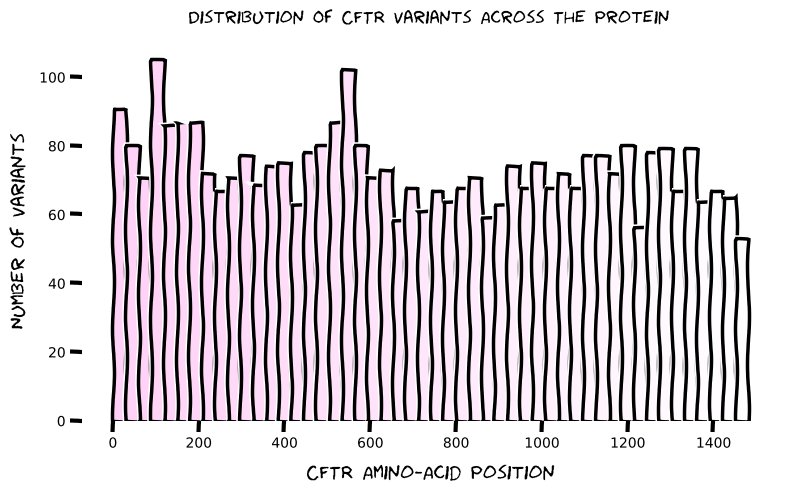

In [ ]:
textcolor = "#000000"
bgcolor = "#ffffff"
gridcolor = "#000000"

customgradient = LinearSegmentedColormap.from_list("pink_to_white", ["#ffd1f7", "#ffffff"])

mpl.rcParams['figure.facecolor'] = bgcolor
mpl.rcParams['axes.facecolor'] = bgcolor

with plt.xkcd():
  fig, ax = plt.subplots(figsize=(8, 5), facecolor=bgcolor)
  ax.set_facecolor(bgcolor)

  n, bins, patches = ax.hist(
      variants_df["Position"],
      bins=50,
      edgecolor='000000',
      alpha=1.0,
      linewidth=2.5,
      zorder=3
      )

  [patch.set_facecolor(customgradient(i / 50)) for i, patch in enumerate(patches)]

  plt.xlabel("CFTR Amino-Acid Position", weight='bold', labelpad=10, color=textcolor, fontname="Humor Sans")
  plt.ylabel("Number Of Variants", weight='bold', labelpad=10, color=textcolor, fontname="Humor Sans")
  plt.title("Distribution Of CFTR Variants Across The Protein", weight='bold', pad=15, color=textcolor, fontsize=13, fontname="Humor Sans")

  ax.tick_params(colors=textcolor, labelsize=10)
  ax.grid(axis='y', linestyle='-', alpha=1.0, color=gridcolor)

  for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [42]:
counts, edges, = pd.cut(
    variants_df["Position"],
    bins=50,
    retbins=True
)

bin_counts = counts.value_counts().sort_index()

print(bin_counts)

Position
(-0.48, 30.6]        91
(30.6, 60.2]         80
(60.2, 89.8]         71
(89.8, 119.4]       105
(119.4, 149.0]       90
(149.0, 178.6]       83
(178.6, 208.2]       87
(208.2, 237.8]       72
(237.8, 267.4]       67
(267.4, 297.0]       75
(297.0, 326.6]       73
(326.6, 356.2]       69
(356.2, 385.8]       74
(385.8, 415.4]       75
(415.4, 445.0]       65
(445.0, 474.6]       76
(474.6, 504.2]       80
(504.2, 533.8]       87
(533.8, 563.4]      102
(563.4, 593.0]       81
(593.0, 622.6]       70
(622.6, 652.2]       73
(652.2, 681.8]       58
(681.8, 711.4]       68
(711.4, 741.0]       62
(741.0, 770.6]       66
(770.6, 800.2]       64
(800.2, 829.8]       68
(829.8, 859.4]       71
(859.4, 889.0]       61
(889.0, 918.6]       61
(918.6, 948.2]       74
(948.2, 977.8]       68
(977.8, 1007.4]      75
(1007.4, 1037.0]     69
(1037.0, 1066.6]     71
(1066.6, 1096.2]     68
(1096.2, 1125.8]     77
(1125.8, 1155.4]     77
(1155.4, 1185.0]     73
(1185.0, 1214.6]     79
(1214.6